##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** [Databazen🤓]

**Student names & numbers:**
* [Xander UijtdeHaag] - [Student no.100546]
* [Jamie Eversdijk] - [Student no.000101617]
* [Jero den Exter] - [Student no.000100883]

---

## 0. Iteration setup

**Import libraries**

In [21]:
# CODE CELL: Import the necessary libraries for this iteration (including scikit-learn models and metrics)
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Load & Merge dataset(s)**

Eigenlijk is de rede dat wij hier een left join gebruiken hetzelfde als in de vorige iteratie. iter3 dataset bevat 2 nieuwe kolommen met ship_id, aangezien iter2_cleaned csv ons opgeschoonde bestaand is van iteratie 2 is deze de left en de iter3 de right. Zodat de hele dataset van iteratie 2 blijft met de kolommen van iteratie 3 erbij met overeenkomende ship_id's

Tuurlijk kan right join ook maar dan zou je de bestanden om moeten draaien dus iter 2 csv wordt df2 en iter3 csv wordt df1 want anders ben je alle data van iteratie 2 kwijt.

En we willen alle ship_id's van iteratie 2 houden dus ook geen inner join om onnodig dataverlies te voorkomen.

In [2]:
# CODE CELL: Import the necessary datasets for this iteration.
# Load your fully cleaned dataset from Iteration 2 AND the new performance logs.
# Merge them together based on the Ship_ID
df1 = pd.read_csv("Data/ship_inspections_iter2_cleaned.csv")
df2 = pd.read_csv("Data/ship_performance_logs_iter3.csv")

merged_df = pd.merge(df1, df2, on="Ship_ID", how="left")

merged_df.to_csv("Data/ship_inspections_iter3_merged.csv", index=False)

df = pd.read_csv("Data/ship_inspections_iter3_merged.csv")

---

## 1. Business Understanding

**Situation description**

*Describe the final problem. Why is Nebula Brokerage moving from the simple models (iterations 1 and 2) to a machine learning approach?*

**Business objective(s)**

*Justify why an AI-driven pipeline (predicting both Galactic Credits and Condition) adds business value.*

**Data mining goal(s)**

*Explain the two modeling tasks for this iteration.*

**Success criteria**

*Determine the success criteria.*

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

De Describe laat al gelijk een aantal dingen opvallen aan Lighyears travelled. Als eerst zie je dat min en max heel ver van het gemiddelde afzitten er zitten dus zeker uitschieters in. Verder als je naar de count van ship_ID kijkt en naar Lightyears zie je ook al gelijk dat er een aantal missen. Dit betekend dat we te maken hebben met data die niet heel goed te vertouwen is. Ook is het gemiddelde groter dan de mediaan en dus zal het rechts scheef zijn of positief.

In [3]:
# CODE CELL: Show basic statistics and information for the final merged dataset
df.describe()

,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Lightyears_Traveled
count,3.603060e+05,360306.000000,360306.000000,360306.000000,353811.000000
mean,7.311483e+09,19232.728903,7511.284225,70.657830,104.839485
std,4.381778e+06,14286.210766,9.015043,42.940156,88.941682
min,7.301583e+09,501.000000,7400.000000,30.000000,0.000000
25%,7.308096e+09,7950.000000,7508.000000,40.000000,30.622182
50%,7.312599e+09,15990.000000,7513.000000,60.000000,85.496024
75%,7.315244e+09,27990.000000,7517.000000,80.000000,157.572045
max,7.317101e+09,99999.000000,7522.000000,360.000000,1559.606111


**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

Wij hebben gekozen om spearman te gebruiken voor correlatie. Dit hebben wij gedaan omdat je hierboven kan zien dat Galactic credits, Reactor power en Lightyears traveled rechts scheef zijn. Voor Pearson moeten ze normaal verdeeld zijn. Verder zijn er grote uitschieters bij Lighyears traveled en ook wel bij Galactic Credits. Reactor power heeft ook redelijk grote uitschieter. Hierdoor leek het ons het beste om spearman te gebruiken. De heatmap laat zien dat er een aantal verbanden zijn. Redelijk sterk positieve correlatie bij Galactic credits en Model cycle. Zwak positief bij Galactic credits en Reactor power. Sterk negatief bij Galactic credits en Lightyears traveled en sterk negatief bij Lightyears traveled en Model Cycle. Hieronder gaan wij deze correlaties nog verder visualiseren om een beter beeld hierbij te krijgen.

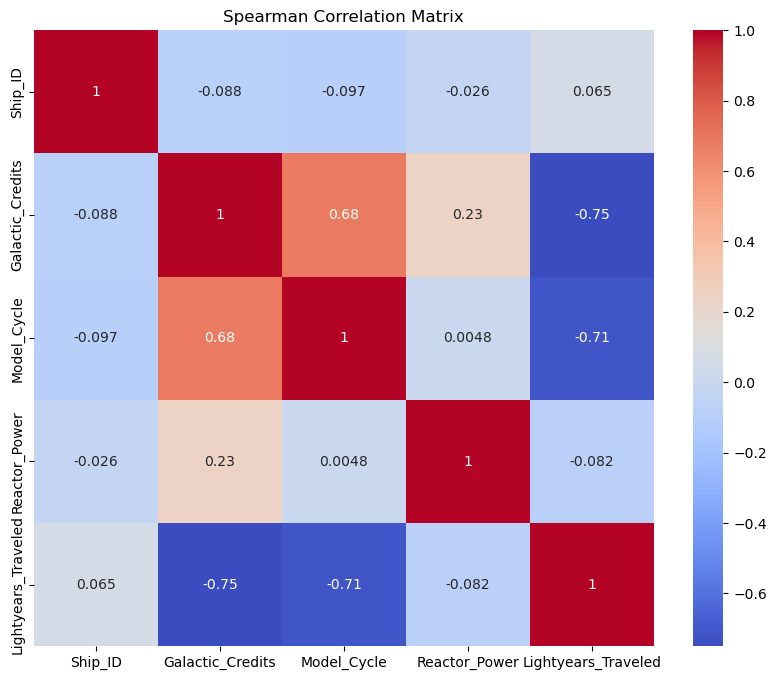

In [35]:
nummer_df = df.select_dtypes(include='number')
corr_matrix = nummer_df.corr(method='spearman')
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Spearman Correlation Matrix")
plt.show()

Deze scatterplot is gemaakt om te kijken welke prijs van de schepen bij welke lightyears travelled hoort. Er is gekozen voor een scatterplot omdat we met 2 numerieke waardes werken. Dit leek ons het beste omdat je anders bijvoorbeeld bij een plot bar je veel te veel verschillende opties krijgt. Je zou kunnen zeggen dat schepen die niet veel lightyears travelled hebben elke prijs kunnen hebben. Hoe meer lightyears travelled hoe goedkoper de schepen worden. Dit is niet 100% voor elk schip zo, maar het is wel te zien dat er iets gaande is. Waarschijnlijk is er een sterke negatieve correlatie want hoe hoger de prijs hoe lager de lightyears travelled. Dit is ook logisch, want hoe meer je met een schip vliegt hoe minder het waard wordt.

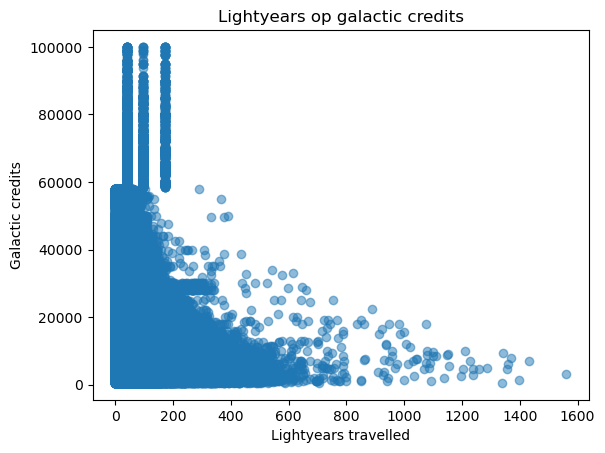

In [36]:
# CODE CELL: Generate visualizations for the new features
plt.scatter(df['Lightyears_Traveled'], df['Galactic_Credits'], alpha=0.5)
plt.title('Lightyears op galactic credits')
plt.xlabel('Lightyears travelled')
plt.ylabel('Galactic credits')
plt.show()

Deze scatterplot laat niet echt een negatieve correlatie zien. Dit komt waarschijnlijk omdat model cycle een kleine range heeft en Lightyears traveled juist een grote range heeft. Verder hebben wij niet echt een manier gevonden om dit beter te laten zien. Je zou in dit geval van de scatterplot zelfs kunnen zeggen dat er een positief verband is.

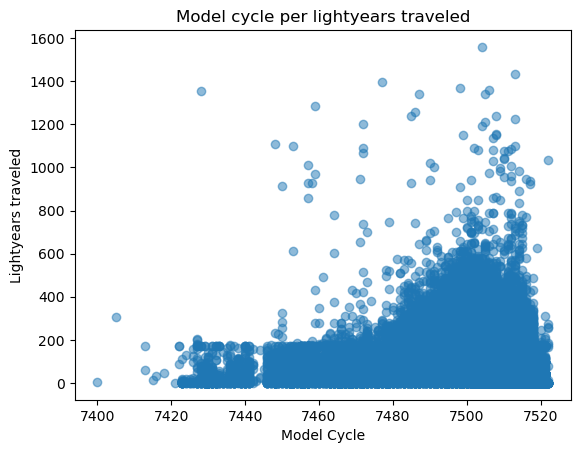

In [41]:
plt.scatter(df['Model_Cycle'], df['Lightyears_Traveled'], alpha=0.5)
plt.title('Model cycle per lightyears traveled')
plt.xlabel('Model Cycle')
plt.ylabel('Lightyears traveled')
plt.show()

Zoals je ziet is imperial certified de klas met de meeste schepen. De minste zijn unknown. Scrap en stolen zijn ongeveer evenveel als elkaar. Wij hebben gekozen om deze grafiek te gebruiken een bar plot omdat deze het beste visueele beeld geeft per categorie.

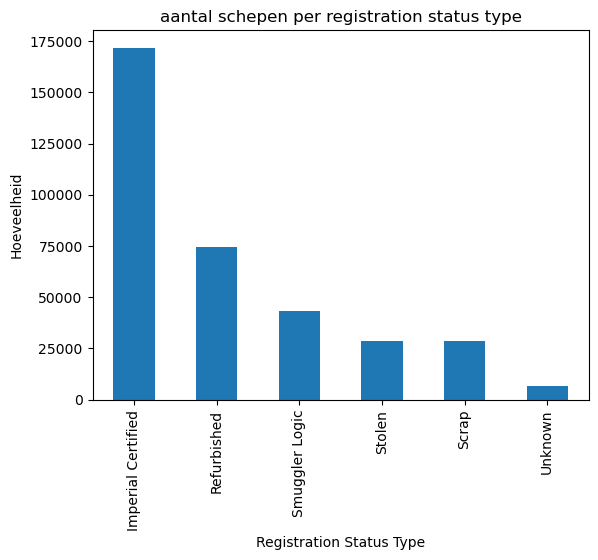

In [5]:
df['Registration_Status'].value_counts().plot.bar()
plt.xlabel("Registration Status Type")
plt.ylabel("Hoeveelheid")
plt.title("aantal schepen per registration status type")
plt.show()

De boxplot laat zien hoeveel lightyears traveled hoort bij welke Hull Integrity. Je kan zien dat Pristine het laagste is en daarna operational komt. Daarna komt cricital. Het bouwt soort van op naar boven. Er is gekozen voor boxplots omdat dit ons het handigste leek. Omdat je met numerieke waarde werkt waar er erg veel van zijn is het moeilijk om dit precies te laten zien zonder waardes te verliezen. We hebben gekozen voor stapjes van 200 omdat dit niet te veel waardes verliest. Het laat alles wel duidelijk genoeg zien en we missen geen belangrijke waardes.

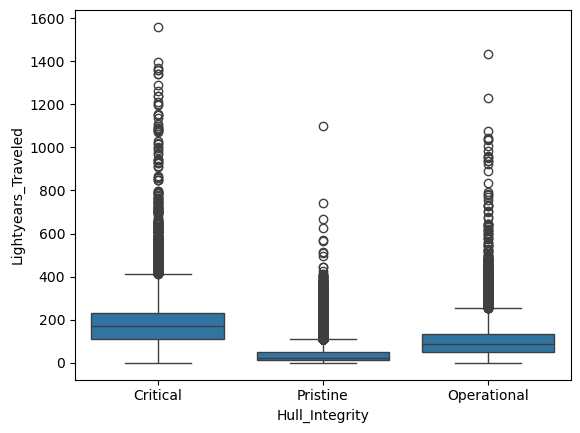

In [6]:
sns.boxplot(x='Hull_Integrity', y='Lightyears_Traveled', data=df)

plt.show()

Je ziet bij dit figuur al snel dat er correlatie is tussen stolen en critical. Dit komt omdat er ongeveer 25000 critical schepen stolen zijn. Bij pristine en opperational is het bij elkaar opgeteld ongeveer 3000. Verder zien we dat Imperial Certified bij Pristine en Operational het hoogste zijn. Dit komt waarschijnlijk omdat dit de meest voorkomende waardes zijn. 

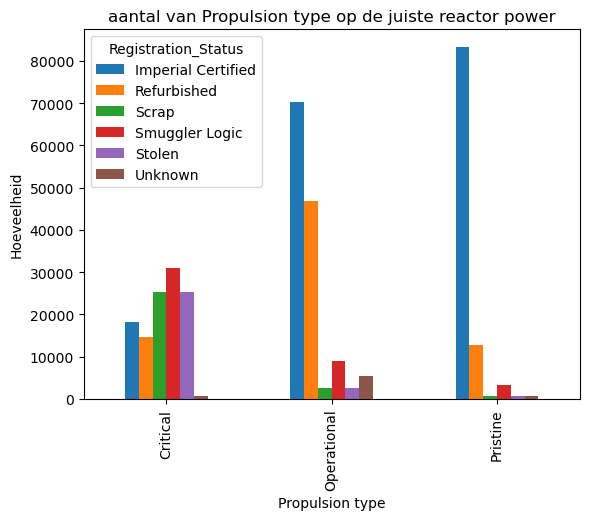

In [7]:
df.groupby('Hull_Integrity')['Registration_Status'].value_counts().unstack().plot.bar()
plt.xlabel("Propulsion type")
plt.ylabel("Hoeveelheid")
plt.title("aantal van Propulsion type op de juiste reactor power")
plt.show()

Er staan geen typfouten in de rij van registration status. Voor de Light years traveled zijn niet zo zeer typfouten die wij hebben gevonden. Eigenlijk alleen best rare uitschieters. Er is een 0 en een 1500.

In [20]:
df['Registration_Status'].value_counts()

Registration_Status
Imperial Certified    171756
Refurbished            74363
Smuggler Logic         43277
Stolen                 28818
Scrap                  28808
Unknown                13284
Name: count, dtype: int64

**Data insights and data quality**

* **Insights:** Does high mileage lower the price? Does a 'Stolen' status correlate with critical hull condition?
* **Quality issues:** Document any missing values and other issues

---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

Aangezien we nu 2 kolommen erbij hebben met een aantal lege waardes moeten we deze op een manier weer vullen, aangezien bij sommige de registration_status al op unknown staat is het logisch om de lege waardes deze zelfde status te geven, aangezien er geen veilige manier is om die status op een andere manier in te vullen.

Voor de lightyears travelled hebben we dit zo aangepakt. Er is een negatieve correlatie tussen de staat van het schip en het aantal gereisde lightyears, vullen we ontbrekende waarden in op basis van die relatie. Schepen in slechte staat hebben vaak meer gereisd dan schepen in goede staat. Daarom vervangen we ontbrekende light years travelled bij schepen met een critical hull integrity door het gemiddelde aantal lightyears van alle schepen met dezelfde hull-status, en daarbij ook op diezelfde manier voor de operational en pristine integrity. Aangezien het niet eerlijk is om de gemiddelde te pakken van de gehele kolom aangezien critical schepen deze gereisde tijd verhogen voor de pristine schepen met lege waardes.

En de laatste command geeft weer dat er geen lege waardes meer zijn in het csv bestand

In [8]:
df_clean = df

df_clean['Registration_Status'] = df_clean['Registration_Status'].fillna('Unknown')

df_clean.loc[
    (df_clean['Hull_Integrity'] == 'Pristine') & (df_clean['Lightyears_Traveled'].isna()),
    'Lightyears_Traveled'
] = df_clean.loc[
    df_clean['Hull_Integrity'] == 'Pristine',
    'Lightyears_Traveled'
].mean()

df_clean.loc[
    (df_clean['Hull_Integrity'] == 'Operational') & (df_clean['Lightyears_Traveled'].isna()),
    'Lightyears_Traveled'
] = df_clean.loc[
    df_clean['Hull_Integrity'] == 'Operational',
    'Lightyears_Traveled'
].mean()

df_clean.loc[
    (df_clean['Hull_Integrity'] == 'Critical') & (df_clean['Lightyears_Traveled'].isna()),
    'Lightyears_Traveled'
] = df_clean.loc[
    df_clean['Hull_Integrity'] == 'Critical',
    'Lightyears_Traveled'
].mean()

df_clean.to_csv("Data/ship_inspections_iter3_cleaned.csv", index=False)

df.isna().sum()

Ship_ID                0
Galactic_Credits       0
Model_Cycle            0
Ship_Manufacturer      0
Sector                 0
Hull_Integrity         0
Reactor_Power          0
Propulsion_Type        0
Ship_Class             0
Lightyears_Traveled    0
Registration_Status    0
dtype: int64

**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

**One-hot encoding**
Om deze categorie kolommen om te zetten in een format wat een model kan gebruiken moeten we de categorieen opslitsen in getallen dus elke soort kolom, dus bijvoorbeeld bij hull integrity pristine, operational en critical. Dit gebeurd via one-hot encoding, daarvan maak je bij elke categorie een kolom waarin true or false staat (0 of 1). Zo kan een model lezen wanneer een kolom een bepaalde categorie is en daarop verder werken. Hierbij hebben we een nieuw bestand gemaakt waarin deze encoding gebruikt wordt want anders is het voor een mens heel irritant om te lezen 

**Dataset split**
Hierin hebben wij de dataset gesplitst in train en test (80/20). Dit is nodig om het model eerlijk te evalueren, omdat het wordt getest op data die het nog niet eerder heeft gezien. Hierdoor voorkomen we dat het model de trainingsdata uit het hoofd leert (overfitting) en krijgen we een realistischer beeld van hoe goed het model presteert op nieuwe data. Zodat het model alle data eerlijk bekijkt zonder enige bias.

In [23]:
# CODE CELL: Apply feature ecoding and define your features (X)
categorical_cols = ['Ship_Manufacturer', 'Sector', 'Hull_Integrity',
                    'Propulsion_Type', 'Ship_Class', 'Registration_Status']

# one-hot encoding d.m.v. pd.get_dummies() en drop_first=False om alle categorieën te behouden
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)

df_encoded.to_csv("Data/ship_inspections_iter3_encoded.csv", index=False)

from sklearn.model_selection import train_test_split

# X = alles behalve de target # y = target Lightyears_Traveled #
X = df_clean.drop('Lightyears_Traveled', axis=1)
y = df_clean['Lightyears_Traveled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

In [11]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [12]:
# CODE CELL: Train-Test split & train the Decision Tree model.

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

In [13]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are thr scores of this regression model better than Iteration 1? Why?*
* *Are the scores of the decision tree better than your manual rules from Iteration 2? Why?*

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Student name 1 | *Contribution description* | *Personal lessons learned this iteration* |
| Jamie Eversdijk | Data preparation, Data understanding | Ik heb vooral geleerd hoe je die one hot encoding model toepast op categorie data kolommen, dit vond ik best te doen alleen het bestand wat ik er toen uitkreeg was niet heel leuk om naar te kijken. Dus had ik eerder besloten om deze bestanden apart te doen van de normale met gewoon de data kolommen met categorieën. Verder heb ik door geleerd hoe je correlaties moet herkennen en daarbij lege kolommen moet invullen, bijvoorbeeld de keuze om het gemiddelde te pakken van light years op elke categorie Hull_Integrity.|
| Jero den Exter | Data preperation, Evaluation | Ik heb geleerd over spearman en pearson. Ik liep vast bij het bepalen of er spearman of pearson gebruikt moest worden, want voor mijn gevoel kon pearson bij model cycle en de rest bij spearman. Verder heb ik ook gekeken naar modeling. Modeling heb ik gevonden dat het lijkt op het model van iteratie 1 en 2. Ik liep hier niet zo zeer vast. |